In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from time import time
import anndata as ad
import scanpy as sc
import copy
from umap import UMAP
import leidenalg as la


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
nodes = pd.read_parquet('./data/phenograph_clustering/nodes_phenotyped')

In [10]:
nodes.columns

Index(['Object', '89Y-Collagen-I', '142Nd-CA9', '143Nd-Vimentin', '144Nd-CD14',
       '145Nd-CD31', '146Nd-CD11b', '147Sm-CD163', '148Nd-Pan-Keratin',
       '149Sm-CD15', '150Nd-CD274', '151Eu-LYVE1', '153Eu-CD16', '154Sm-CD11c',
       '155Gd-FoxP3', '156Gd-CD4', '158Gd-E-Cadherin', '159Tb-CD68',
       '160Gd-FAP', '161Dy-CD20', '162Dy-CD8a', '163Dy-CD206', '164Dy-KRT17',
       '166Er-CD74', '167Er-Granzyme_B', '168Er-Ki-67', '169Tm-FOLR2',
       '170Er-CD3', '171Yb-MS4A4A', '172Yb-S100A2', '173Yb-CD45RO',
       '174Yb-Keratin_8_18', '176Yb-Histone_H3', '191Ir-DNA1', '193Ir-DNA2',
       '195Pt-ICSK1', '196Pt-ICSK2', '198Pt-ICSK3', '209Bi-aSMA', 'Phenotype',
       'area', 'centroid-0', 'centroid-1', 'axis_major_length',
       'axis_minor_length', 'eccentricity'],
      dtype='object')

In [ ]:
#Je récupère nodes avec arcsinh normalization
import os
import glob
import re

import pandas as pd
import anndata as ad


# --------------------------------------------------
# Dossier contenant les fichiers nodes
# --------------------------------------------------

save_dir = "./data/phenograph_clustering/nodes_phenotyped" # where the nodes are stored
out_dir = "./data/nodes_arcsinh"


# --------------------------------------------------
# Colonnes de métadonnées
# --------------------------------------------------

meta_cols = [
    "Object",
    "Phenotype",
    "area",
    "centroid-0",
    "centroid-1",
    "axis_major_length",
    "axis_minor_length",
    "eccentricity",
    #"source_file",
    #"Niche",
]


# --------------------------------------------------
# Lecture de tous les fichiers
# --------------------------------------------------

adatas = []

files = sorted(
    glob.glob(
        os.path.join(save_dir, "nodes*.parquet")
    )
)

print(f"{len(files)} fichiers trouvés")


for file in files:

    print(os.path.basename(file))

    df = pd.read_parquet(file)

    # ------------------------------------------
    # Extraction patient + sample
    # ------------------------------------------

    basename = os.path.basename(file)

    m = re.search(
        r"patient-(\d+)_sample-(\d+)",
        basename
    )

    if m is None:
        raise ValueError(
            f"Impossible d'extraire patient/sample depuis {basename}"
        )

    patient = int(m.group(1))
    sample = int(m.group(2))

    patient_id = f"P{patient}"
    sample_id = f"S{sample}"

    df["cell_id"] = (
        patient_id
        + "_"
        + sample_id
        + "_"
        + df["Object"].astype(str)
    )

    df.index = df["cell_id"]

   


    # ------------------------------------------
    # Matrice protéines
    # ------------------------------------------

    X = df.drop(
        columns=meta_cols + ["cell_id"]
    )

    X.index = df.index

    # ------------------------------------------
    # Métadonnées
    # ------------------------------------------

    obs = df[
        meta_cols + ["cell_id"]
    ].copy()

    obs.index = df.index

    obs["patient_sample"] = sample_id

    obs["patient"] = patient_id
    obs["sample"] = sample_id
    obs["patient_sample"] = (
        patient_id + "_" + sample_id
    )


    # ------------------------------------------
    # AnnData
    # ------------------------------------------

    adata = ad.AnnData(
        X=X,
        obs=obs,
        var=pd.DataFrame(index=X.columns)
    )

    # ------------------------------------------
    # Coordonnées spatiales
    # ------------------------------------------

    adata.obsm["spatial"] = df[
        ["centroid-0", "centroid-1"]
    ].to_numpy()


    adatas.append(adata)


# --------------------------------------------------
# Concaténation
# --------------------------------------------------

adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    index_unique=None
)

print(adata)

import numpy as np


# --------------------------------------------------
# Arcsinh sur la matrice protéines
# --------------------------------------------------

cofactor = 5

adata.X = np.arcsinh(
    adata.X / cofactor
)

print("Arcsinh appliqué")


# --------------------------------------------------
# Dossier export parquet
# --------------------------------------------------



os.makedirs(out_dir, exist_ok=True)


## --------------------------------------------------
# Reconstruction des nodes par patient/sample
# --------------------------------------------------

# Liste complète des marqueurs après concaténation
all_markers = adata.var_names.tolist()


# Matrice protéines arcsinh
X_arcsinh = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=all_markers
)


# Métadonnées
obs = adata.obs.copy()


# dataframe complet
df_all = pd.concat(
    [
        obs,
        X_arcsinh
    ],
    axis=1
)


# --------------------------------------------------
# Export séparé avec tous les marqueurs
# --------------------------------------------------

for patient_sample, df_group in df_all.groupby("patient_sample"):

    patient = df_group["patient"].iloc[0]
    sample = df_group["sample"].iloc[0]

    patient_num = patient.replace("P", "")
    sample_num = sample.replace("S", "")


    out_name = (
        f"nodes_patient-{patient_num}"
        f"_sample-{sample_num}.parquet"
    )


    out_path = os.path.join(
        out_dir,
        out_name
    )


    # ------------------------------------------
    # Forcer toutes les colonnes marqueurs
    # ------------------------------------------

    for marker in all_markers:
        if marker not in df_group.columns:
            df_group[marker] = 0


    # remettre l'ordre :
    # métadonnées puis tous les marqueurs
    df_group = df_group[
        meta_cols
        + [
            "cell_id",
          
        ]
        + all_markers
    ]


    # export
    df_group.to_parquet(
        out_path,
        index=False
    )


    print(
        "Export :",
        out_path,
        "| marqueurs :",
        len(all_markers)
    )


print("Tous les fichiers exportés avec les mêmes marqueurs.")

43 fichiers trouvés
nodes_patient-01_sample-01.parquet
nodes_patient-01_sample-02.parquet
nodes_patient-01_sample-03.parquet
nodes_patient-01_sample-04.parquet
nodes_patient-02_sample-01.parquet
nodes_patient-02_sample-02.parquet
nodes_patient-02_sample-03.parquet
nodes_patient-02_sample-04.parquet
nodes_patient-03_sample-01.parquet
nodes_patient-03_sample-02.parquet
nodes_patient-03_sample-03.parquet
nodes_patient-04_sample-01.parquet
nodes_patient-04_sample-02.parquet
nodes_patient-04_sample-03.parquet
nodes_patient-04_sample-04.parquet
nodes_patient-04_sample-05.parquet
nodes_patient-05_sample-01.parquet
nodes_patient-05_sample-02.parquet
nodes_patient-05_sample-03.parquet
nodes_patient-05_sample-04.parquet
nodes_patient-06_sample-01.parquet
nodes_patient-06_sample-02.parquet
nodes_patient-06_sample-03.parquet
nodes_patient-06_sample-04.parquet
nodes_patient-07_sample-01.parquet
nodes_patient-07_sample-02.parquet
nodes_patient-07_sample-03.parquet
nodes_patient-07_sample-04.parquet


In [4]:
marker_col

'A100A2_status'

In [ ]:
#Je récupère nodes avec arcsinh et phénotypes changées selon les states que j'ai définis pour macrophage et tumour cells

import os
import glob
import re

import pandas as pd
import anndata as ad


# --------------------------------------------------
# Dossier contenant les fichiers nodes
# --------------------------------------------------

save_dir = "./data/phenograph_clustering/nodes_phenotyped" # where the nodes are stored
out_dir = "./data/nodes_arcsinh_states_labeled/S100A2_and_macrostates_labeled/leiden_states"

df_krt17 = pd.read_csv("OUTPUT_arcsinh/cell_states/tumor_cells_S100A2_status/Tumour_S100A2_status.csv")
df_macro = pd.read_csv("OUTPUT_arcsinh/cell_states/20/states_def/macrophages/definition/cell_leiden_clean_to_cell_id_mapping.csv")

marker = 'S100A2'
marker_col = f'{marker}_status'

# --------------------------------------------------
# Choix du renommage des macrophages
# --------------------------------------------------

# "state" -> Macrophage_state_1, 2, 3...
# "leiden_clean" -> noms de clusters
MACRO_LABEL = "leiden_clean"          # "state" ou "leiden_clean"


# --------------------------------------------------
# Colonnes de métadonnées
# --------------------------------------------------

meta_cols = [
    "Object",
    "Phenotype",
    "area",
    "centroid-0",
    "centroid-1",
    "axis_major_length",
    "axis_minor_length",
    "eccentricity",
    "Macro_label",
    marker_col,

    #"source_file",
    #"Niche",
]


# --------------------------------------------------
# Lecture de tous les fichiers
# --------------------------------------------------

adatas = []

files = sorted(
    glob.glob(
        os.path.join(save_dir, "nodes*.parquet")
    )
)

print(f"{len(files)} fichiers trouvés")


for file in files:

    print(os.path.basename(file))

    df = pd.read_parquet(file)

    # ------------------------------------------
    # Extraction patient + sample
    # ------------------------------------------

    basename = os.path.basename(file)

    m = re.search(
        r"patient-(\d+)_sample-(\d+)",
        basename
    )

    if m is None:
        raise ValueError(
            f"Impossible d'extraire patient/sample depuis {basename}"
        )

    patient = int(m.group(1))
    sample = int(m.group(2))

    patient_id = f"P{patient}"
    sample_id = f"S{sample}"

    df["cell_id"] = (
        patient_id
        + "_"
        + sample_id
        + "_"
        + df["Object"].astype(str)
    )

    



    # --------------------------------------------------
    # Mapping KRT17
    # --------------------------------------------------

    krt17_map = df_krt17.set_index("cell_id")[marker_col]
    df[marker_col] = df["cell_id"].map(krt17_map)

    # --------------------------------------------------
    # Mapping macrophages
    # --------------------------------------------------

    macro_map = df_macro.set_index("cell_id")[MACRO_LABEL]
    df["Macro_label"] = df["cell_id"].map(macro_map)



        # --------------------------------------------------
    # Tumour cells
    # --------------------------------------------------

    tumour_mask = df["Phenotype"].isin(
        [
            "Epithelial tumour",
            "Epithelial tumour (basal)",
            "Epithelial Tumour(basal)"
        ]
    )

    df.loc[
        tumour_mask & (df[marker_col] == f"{marker}+"),
        "Phenotype"
    ] = f"Tumour cells ({marker}+)"

    df.loc[
        tumour_mask & (df[marker_col] == f"{marker}-"),
        "Phenotype"
    ] = f"Tumour cells ({marker}-)"


    # --------------------------------------------------
    # Macrophages
    # --------------------------------------------------

    macro_mask = df["Phenotype"].isin(["Macrophage", "TAM", "TAM M2"])

    df.loc[macro_mask, "Phenotype"] = (
        "Macrophage_state_"
        + df.loc[macro_mask, "Macro_label"]
            .astype("Int32")
            .astype(str)
    )






    df.index = df["cell_id"]
    # ------------------------------------------
    # Matrice protéines
    # ------------------------------------------

    X = df.drop(
        columns=meta_cols + ["cell_id"]
    )

    X.index = df.index

    # ------------------------------------------
    # Métadonnées
    # ------------------------------------------

    obs = df[
        meta_cols + ["cell_id"]
    ].copy()

    obs.index = df.index

    obs["patient_sample"] = sample_id

    obs["patient"] = patient_id
    obs["sample"] = sample_id
    obs["patient_sample"] = (
        patient_id + "_" + sample_id
    )


    # ------------------------------------------
    # AnnData
    # ------------------------------------------

    adata = ad.AnnData(
        X=X,
        obs=obs,
        var=pd.DataFrame(index=X.columns)
    )

    # ------------------------------------------
    # Coordonnées spatiales
    # ------------------------------------------

    adata.obsm["spatial"] = df[
        ["centroid-0", "centroid-1"]
    ].to_numpy()


    adatas.append(adata)


# --------------------------------------------------
# Concaténation
# --------------------------------------------------

adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    index_unique=None
)

print(adata)

import numpy as np


# --------------------------------------------------
# Arcsinh sur la matrice protéines
# --------------------------------------------------

cofactor = 5

adata.X = np.arcsinh(
    adata.X / cofactor
)

print("Arcsinh appliqué")


# --------------------------------------------------
# Dossier export parquet
# --------------------------------------------------



os.makedirs(out_dir, exist_ok=True)


## --------------------------------------------------
# Reconstruction des nodes par patient/sample
# --------------------------------------------------

# Liste complète des marqueurs après concaténation
all_markers = adata.var_names.tolist()


# Matrice protéines arcsinh
X_arcsinh = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=all_markers
)


# Métadonnées
obs = adata.obs.copy()


# dataframe complet
df_all = pd.concat(
    [
        obs,
        X_arcsinh
    ],
    axis=1
)


# --------------------------------------------------
# Export séparé avec tous les marqueurs
# --------------------------------------------------

for patient_sample, df_group in df_all.groupby("patient_sample"):

    patient = df_group["patient"].iloc[0]
    sample = df_group["sample"].iloc[0]

    patient_num = patient.replace("P", "")
    sample_num = sample.replace("S", "")


    out_name = (
        f"nodes_patient-{patient_num}"
        f"_sample-{sample_num}.parquet"
    )


    out_path = os.path.join(
        out_dir,
        out_name
    )


    # ------------------------------------------
    # Forcer toutes les colonnes marqueurs
    # ------------------------------------------

    for marker in all_markers:
        if marker not in df_group.columns:
            df_group[marker] = 0


    # remettre l'ordre :
    # métadonnées puis tous les marqueurs
    df_group = df_group[
        meta_cols
        + [
            "cell_id",
          
        ]
        + all_markers
    ]


    # export
    df_group.to_parquet(
        out_path,
        index=False
    )


    print(
        "Export :",
        out_path,
        "| marqueurs :",
        len(all_markers)
    )


print("Tous les fichiers exportés avec les mêmes marqueurs.")

43 fichiers trouvés
nodes_patient-01_sample-01.parquet
nodes_patient-01_sample-02.parquet
nodes_patient-01_sample-03.parquet
nodes_patient-01_sample-04.parquet
nodes_patient-02_sample-01.parquet
nodes_patient-02_sample-02.parquet
nodes_patient-02_sample-03.parquet
nodes_patient-02_sample-04.parquet
nodes_patient-03_sample-01.parquet
nodes_patient-03_sample-02.parquet
nodes_patient-03_sample-03.parquet
nodes_patient-04_sample-01.parquet
nodes_patient-04_sample-02.parquet
nodes_patient-04_sample-03.parquet
nodes_patient-04_sample-04.parquet
nodes_patient-04_sample-05.parquet
nodes_patient-05_sample-01.parquet
nodes_patient-05_sample-02.parquet
nodes_patient-05_sample-03.parquet
nodes_patient-05_sample-04.parquet
nodes_patient-06_sample-01.parquet
nodes_patient-06_sample-02.parquet
nodes_patient-06_sample-03.parquet
nodes_patient-06_sample-04.parquet
nodes_patient-07_sample-01.parquet
nodes_patient-07_sample-02.parquet
nodes_patient-07_sample-03.parquet
nodes_patient-07_sample-04.parquet


In [15]:
#Je récupère nodes avec arcsinh et phénotypes changées selon les states que j'ai définis pour macrophage et tumour cells ici double status

import os
import glob
import re

import pandas as pd
import anndata as ad


# --------------------------------------------------
# Dossier contenant les fichiers nodes
# --------------------------------------------------

save_dir = "./data/phenograph_clustering/nodes_phenotyped" # where the nodes are stored
out_dir = "./data/nodes_arcsinh_states_labeled/corrected_double_status_tumour_and_macrostates_labeled/niche_states"

df_double = pd.read_csv(
    "OUTPUT_arcsinh/cell_states/double_status/Cells_double_status.csv"
)
df_macro = pd.read_csv("OUTPUT_arcsinh/cell_states/20/states_def/macrophages4/definition/cell_state_to_cell_id_mapping.csv")



# --------------------------------------------------
# Choix du renommage des macrophages
# --------------------------------------------------

# "state" -> Macrophage_state_1, 2, 3...
# "leiden_clean" -> noms de clusters
MACRO_LABEL = "state"          # "state" ou "leiden_clean"


# --------------------------------------------------
# Colonnes de métadonnées
# --------------------------------------------------

meta_cols = [
    "Object",
    "Phenotype",
    "area",
    "centroid-0",
    "centroid-1",
    "axis_major_length",
    "axis_minor_length",
    "eccentricity",
    "Macro_label",
    "double_status",
]


# --------------------------------------------------
# Lecture de tous les fichiers
# --------------------------------------------------

adatas = []

files = sorted(
    glob.glob(
        os.path.join(save_dir, "nodes*.parquet")
    )
)

print(f"{len(files)} fichiers trouvés")


for file in files:

    print(os.path.basename(file))

    df = pd.read_parquet(file)

    # ------------------------------------------
    # Extraction patient + sample
    # ------------------------------------------

    basename = os.path.basename(file)

    m = re.search(
        r"patient-(\d+)_sample-(\d+)",
        basename
    )

    if m is None:
        raise ValueError(
            f"Impossible d'extraire patient/sample depuis {basename}"
        )

    patient = int(m.group(1))
    sample = int(m.group(2))

    patient_id = f"P{patient}"
    sample_id = f"S{sample}"

    df["cell_id"] = (
        patient_id
        + "_"
        + sample_id
        + "_"
        + df["Object"].astype(str)
    )

    



    # --------------------------------------------------
    # Mapping KRT17
    # --------------------------------------------------

    double_map = df_double.set_index("cell_id")["double_status"]

    df["double_status"] = df["cell_id"].map(double_map)

    # --------------------------------------------------
    # Mapping macrophages
    # --------------------------------------------------

    macro_map = df_macro.set_index("cell_id")[MACRO_LABEL]
    df["Macro_label"] = df["cell_id"].map(macro_map)



        # --------------------------------------------------
    # Tumour cells
    # --------------------------------------------------
    tumour_mask = df["Phenotype"].isin(
        [
            "Epithelial tumour",
            "Epithelial tumour (basal)",
            "Epithelial Tumour(basal)"
        ]
    )

    mapping = {
        "Double positive": "Tumour cells (KRT17+ S100A2+)",
        "KRT17+ S100A2-": "Tumour cells (KRT17+ S100A2-)",
        "KRT17- S100A2+": "Tumour cells (KRT17- S100A2+)",
        "Double negative": "Tumour cells (KRT17- S100A2-)"
    }

    for old, new in mapping.items():

        df.loc[
            tumour_mask &
            (df["double_status"] == old),
            "Phenotype"
        ] = new

    # --------------------------------------------------
    # Macrophages
    # --------------------------------------------------

    macro_mask = df["Phenotype"].isin(["Macrophage", "TAM", "TAM M2"])

    df.loc[macro_mask, "Phenotype"] = (
        "Macrophage_state_"
        + df.loc[macro_mask, "Macro_label"]
            .astype("Int32")
            .astype(str)
    )






    df.index = df["cell_id"]
    # ------------------------------------------
    # Matrice protéines
    # ------------------------------------------

    X = df.drop(
        columns=meta_cols + ["cell_id"]
    )

    X.index = df.index

    # ------------------------------------------
    # Métadonnées
    # ------------------------------------------

    obs = df[
        meta_cols + ["cell_id"]
    ].copy()

    obs.index = df.index

    obs["patient_sample"] = sample_id

    obs["patient"] = patient_id
    obs["sample"] = sample_id
    obs["patient_sample"] = (
        patient_id + "_" + sample_id
    )


    # ------------------------------------------
    # AnnData
    # ------------------------------------------

    adata = ad.AnnData(
        X=X,
        obs=obs,
        var=pd.DataFrame(index=X.columns)
    )

    # ------------------------------------------
    # Coordonnées spatiales
    # ------------------------------------------

    adata.obsm["spatial"] = df[
        ["centroid-0", "centroid-1"]
    ].to_numpy()


    adatas.append(adata)


# --------------------------------------------------
# Concaténation
# --------------------------------------------------

adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    index_unique=None
)

print(adata)

import numpy as np


# --------------------------------------------------
# Arcsinh sur la matrice protéines
# --------------------------------------------------

cofactor = 5

adata.X = np.arcsinh(
    adata.X / cofactor
)

print("Arcsinh appliqué")


# --------------------------------------------------
# Dossier export parquet
# --------------------------------------------------



os.makedirs(out_dir, exist_ok=True)


## --------------------------------------------------
# Reconstruction des nodes par patient/sample
# --------------------------------------------------

# Liste complète des marqueurs après concaténation
all_markers = adata.var_names.tolist()


# Matrice protéines arcsinh
X_arcsinh = pd.DataFrame(
    adata.X,
    index=adata.obs_names,
    columns=all_markers
)


# Métadonnées
obs = adata.obs.copy()


# dataframe complet
df_all = pd.concat(
    [
        obs,
        X_arcsinh
    ],
    axis=1
)


# --------------------------------------------------
# Export séparé avec tous les marqueurs
# --------------------------------------------------

for patient_sample, df_group in df_all.groupby("patient_sample"):

    patient = df_group["patient"].iloc[0]
    sample = df_group["sample"].iloc[0]

    patient_num = patient.replace("P", "")
    sample_num = sample.replace("S", "")


    out_name = (
        f"nodes_patient-{patient_num}"
        f"_sample-{sample_num}.parquet"
    )


    out_path = os.path.join(
        out_dir,
        out_name
    )


    # ------------------------------------------
    # Forcer toutes les colonnes marqueurs
    # ------------------------------------------

    for marker in all_markers:
        if marker not in df_group.columns:
            df_group[marker] = 0


    # remettre l'ordre :
    # métadonnées puis tous les marqueurs
    df_group = df_group[
        meta_cols
        + [
            "cell_id",
          
        ]
        + all_markers
    ]


    # export
    df_group.to_parquet(
        out_path,
        index=False
    )


    print(
        "Export :",
        out_path,
        "| marqueurs :",
        len(all_markers)
    )


print("Tous les fichiers exportés avec les mêmes marqueurs.")

43 fichiers trouvés
nodes_patient-01_sample-01.parquet
nodes_patient-01_sample-02.parquet
nodes_patient-01_sample-03.parquet
nodes_patient-01_sample-04.parquet
nodes_patient-02_sample-01.parquet
nodes_patient-02_sample-02.parquet
nodes_patient-02_sample-03.parquet
nodes_patient-02_sample-04.parquet
nodes_patient-03_sample-01.parquet
nodes_patient-03_sample-02.parquet
nodes_patient-03_sample-03.parquet
nodes_patient-04_sample-01.parquet
nodes_patient-04_sample-02.parquet
nodes_patient-04_sample-03.parquet
nodes_patient-04_sample-04.parquet
nodes_patient-04_sample-05.parquet
nodes_patient-05_sample-01.parquet
nodes_patient-05_sample-02.parquet
nodes_patient-05_sample-03.parquet
nodes_patient-05_sample-04.parquet
nodes_patient-06_sample-01.parquet
nodes_patient-06_sample-02.parquet
nodes_patient-06_sample-03.parquet
nodes_patient-06_sample-04.parquet
nodes_patient-07_sample-01.parquet
nodes_patient-07_sample-02.parquet
nodes_patient-07_sample-03.parquet
nodes_patient-07_sample-04.parquet


In [4]:
# --------------------------------------------------
# Dossier contenant les fichiers nodes à transformer en adata
# --------------------------------------------------

save_dir = "./OUTPUT_arcsinh/niches/analyses_complementaires_niches_20_merged/nodes_cluster_labeled"

In [5]:
# je transforme les parquets en un adata

import os
import glob
import re

import pandas as pd
import anndata as ad


# --------------------------------------------------
# Dossier contenant les fichiers nodes
# --------------------------------------------------

#save_dir = "./OUTPUT_arcsinh/niches/analyses_complementaires_niches_20_merged/nodes_cluster_labeled"


# --------------------------------------------------
# Colonnes de métadonnées
# --------------------------------------------------

meta_cols = [
    "Object",
    "Phenotype",
    "area",
    "centroid-0",
    "centroid-1",
    "axis_major_length",
    "axis_minor_length",
    "eccentricity",
    "source_file",
    "cell_id",
    "Niche",
]


# --------------------------------------------------
# Lecture de tous les fichiers
# --------------------------------------------------

adatas = []

files = sorted(
    glob.glob(
        os.path.join(save_dir, "nodes*.parquet")
    )
)

print(f"{len(files)} fichiers trouvés")


for file in files:

    print(os.path.basename(file))

    df = pd.read_parquet(file)

    # ------------------------------------------
    # Extraction patient + sample
    # ------------------------------------------

    basename = os.path.basename(file)

    m = re.search(
        r"patient-(\d+)_sample-(\d+)",
        basename
    )

    if m is None:
        raise ValueError(
            f"Impossible d'extraire patient/sample depuis {basename}"
        )

    patient = int(m.group(1))
    sample = int(m.group(2))

    patient_id = f"P{patient}"
    sample_id = f"S{sample}"

    

    df.index = df["cell_id"]

   


    # ------------------------------------------
    # Matrice protéines
    # ------------------------------------------

    X = df.drop(
        columns=meta_cols + ["cell_id"]
    )

    X.index = df.index

    # ------------------------------------------
    # Métadonnées
    # ------------------------------------------

    obs = df[
        meta_cols
    ].copy()

    obs.index = df.index

    obs["patient_sample"] = sample_id

    obs["patient"] = patient_id
    obs["sample"] = sample_id
    obs["patient_sample"] = (
        patient_id + "_" + sample_id
    )


    # ------------------------------------------
    # AnnData
    # ------------------------------------------

    adata = ad.AnnData(
        X=X,
        obs=obs,
        var=pd.DataFrame(index=X.columns)
    )

    # ------------------------------------------
    # Coordonnées spatiales
    # ------------------------------------------

    adata.obsm["spatial"] = df[
        ["centroid-0", "centroid-1"]
    ].to_numpy()



    adatas.append(adata)


# --------------------------------------------------
# Concaténation
# --------------------------------------------------

adata = ad.concat(
    adatas,
    join="outer",
    merge="same",
    index_unique=None
)

print(adata)

43 fichiers trouvés
nodes_patient-10_sample-1.parquet
nodes_patient-10_sample-2.parquet
nodes_patient-10_sample-3.parquet
nodes_patient-10_sample-4.parquet
nodes_patient-10_sample-5.parquet
nodes_patient-1_sample-1.parquet
nodes_patient-1_sample-2.parquet
nodes_patient-1_sample-3.parquet
nodes_patient-1_sample-4.parquet
nodes_patient-2_sample-1.parquet
nodes_patient-2_sample-2.parquet
nodes_patient-2_sample-3.parquet
nodes_patient-2_sample-4.parquet
nodes_patient-3_sample-1.parquet
nodes_patient-3_sample-2.parquet
nodes_patient-3_sample-3.parquet
nodes_patient-4_sample-1.parquet
nodes_patient-4_sample-2.parquet
nodes_patient-4_sample-3.parquet
nodes_patient-4_sample-4.parquet
nodes_patient-4_sample-5.parquet
nodes_patient-5_sample-1.parquet
nodes_patient-5_sample-2.parquet
nodes_patient-5_sample-3.parquet
nodes_patient-5_sample-4.parquet
nodes_patient-6_sample-1.parquet
nodes_patient-6_sample-2.parquet
nodes_patient-6_sample-3.parquet
nodes_patient-6_sample-4.parquet
nodes_patient-7_sa

In [6]:
adata

AnnData object with n_obs × n_vars = 543087 × 38
    obs: 'Object', 'Phenotype', 'area', 'centroid-0', 'centroid-1', 'axis_major_length', 'axis_minor_length', 'eccentricity', 'source_file', 'cell_id', 'Niche', 'patient_sample', 'patient', 'sample'
    obsm: 'spatial'

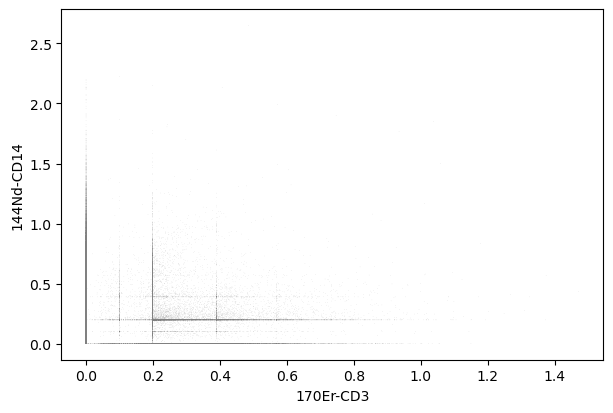

In [9]:
sc.pl.scatter(
    adata,
    x="170Er-CD3",
    y="144Nd-CD14",
    basis=None
)